In [2]:
!pip install scikit-learn statsmodels

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Create a small dataset (you can replace with real data later)
data = {
    "Size_sqft": [1000, 1500, 2000, 2500, 3000, 1200, 1800, 2300, 2700, 3200],
    "Bedrooms":  [2,    3,    3,    4,    4,    2,    3,    4,    4,    5],
    "Age_years": [20,   15,   10,   8,    5,    25,   12,   7,    3,    1],
    "Price":     [300000, 400000, 500000, 600000, 700000, 320000, 480000, 580000, 650000, 780000]
}

df = pd.DataFrame(data)
df

,Size_sqft,Bedrooms,Age_years,Price
0,1000,2,20,300000
1,1500,3,15,400000
2,2000,3,10,500000
3,2500,4,8,600000
4,3000,4,5,700000
5,1200,2,25,320000
6,1800,3,12,480000
7,2300,4,7,580000
8,2700,4,3,650000
9,3200,5,1,780000


In [4]:
# Features and target
X = df[["Size_sqft", "Bedrooms", "Age_years"]]
y = df["Price"]

# Train/test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [5]:
print("Intercept (b0):", model.intercept_)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})
print(coef_df)

# Interpretation example (text)
for f, c in zip(coef_df['feature'], coef_df['coefficient']):
    print(f" -> 1 unit increase in {f} changes Price by approximately {c:,.2f} (holding others constant)")


Intercept (b0): 174709.69289827254
     feature   coefficient
0  Size_sqft    149.280230
1   Bedrooms  23913.147793
2  Age_years  -3800.383877
 -> 1 unit increase in Size_sqft changes Price by approximately 149.28 (holding others constant)
 -> 1 unit increase in Bedrooms changes Price by approximately 23,913.15 (holding others constant)
 -> 1 unit increase in Age_years changes Price by approximately -3,800.38 (holding others constant)


In [6]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Train metrics
r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)

# Test metrics
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

n_train = X_train.shape[0]
p = X_train.shape[1]

print("TRAIN -> R2:", r2_train, "Adj R2:", adjusted_r2(r2_train, n_train, p), "RMSE:", rmse_train, "MAE:", mae_train)
print("TEST  -> R2:", r2_test, "Adj R2:", adjusted_r2(r2_test, X_test.shape[0], p), "RMSE:", rmse_test, "MAE:", mae_test)


TRAIN -> R2: 0.9963395911604181 Adj R2: 0.9926791823208363 RMSE: 8783.646968761883 MAE: 7791.335344118449
TEST  -> R2: 0.9915483697324402 Adj R2: 1.0169032605351196 RMSE: 12921.557618406207 MAE: 12906.269993602027


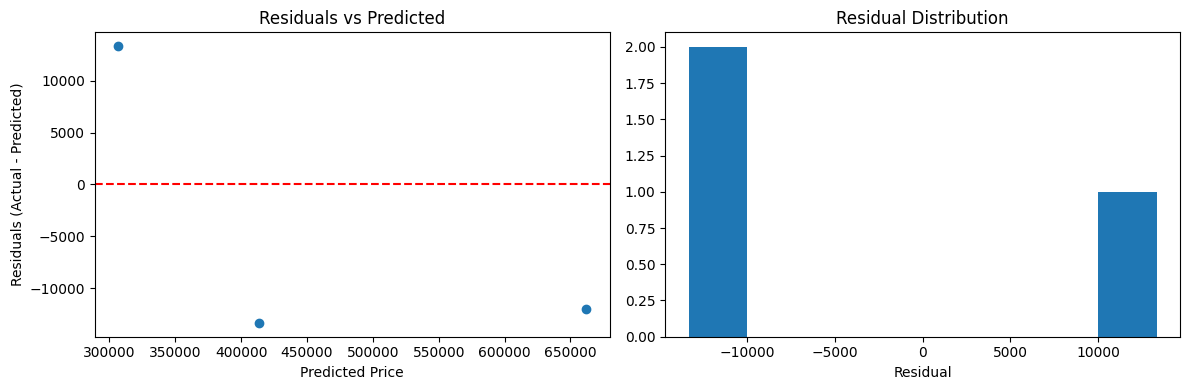

In [7]:
# Residuals for test set
residuals = y_test - y_pred_test

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(y_pred_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")

plt.subplot(1,2,2)
plt.hist(residuals, bins=8)
plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()


In [8]:
# Optional: requires statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_for_vif = sm.add_constant(X)  # add intercept for VIF calc
vif_df = pd.DataFrame()
vif_df["feature"] = X_for_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]
vif_df = vif_df[vif_df["feature"] != "const"]  # drop const row if you like
print(vif_df)


     feature        VIF
1  Size_sqft  13.436944
2   Bedrooms  14.333407
3  Age_years  11.307523


In [9]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation on the whole dataset
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("5-fold CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())


5-fold CV R2 scores: [0.95697314 0.9455745  0.99961251 0.9389224  0.90498003]
Mean CV R2: 0.9492125147683396


In [10]:
# Save model coefficients to a csv for record
coef_df.to_csv("day2_coefficients.csv", index=False)
print("Saved coefficients to day2_coefficients.csv")


Saved coefficients to day2_coefficients.csv
